In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
tmin = 0
tmax = 40
h_values = [0.3, 0.15, 0.075]

# --- Define the Van der Pol diffeq as a system of diffeq's ---
def system(y):
  x1, x2 = y
  dydt = np.array([x2, -(x1**2 - 1)*x2 - x1])  # Return the system of differential equations
  return dydt

# --- Define functions for each method so plotting is easier ---
def AB(y_ab, h, tmin=0, tmax=40):
  N = int((tmax - tmin) / h)
  
  y_ab[:,1] = y_ab[:,0] + h * system(y_ab[:,0])
  for n in range(1,N):
    y_ab[:,n+1] = y_ab[:,n] + (h/2)*(3*system(y_ab[:,n]) - system(y_ab[:,n-1]))

  return(y_ab)

def predcorr(y_pc, h, tmin=0, tmax=40):
  N = int((tmax - tmin) / h)
  
  y_pc[:,1] = y_pc[:,0] + h * system(y_pc[:,0])
  for n in range(1,N):

    # Predictor method (2-step Adams-Bashforth)
    y_pred = y_pc[:,n] + (h/2)*(3*system(y_pc[:,n]) - system(y_pc[:,n-1]))

    # Corrector method (1-step Adams-Moulton/trapezoidal)
    y_pc[:,n+1] = y_pc[:,n] + (h/2)*(system(y_pc[:,n]) + system(y_pred))

  return(y_pc)

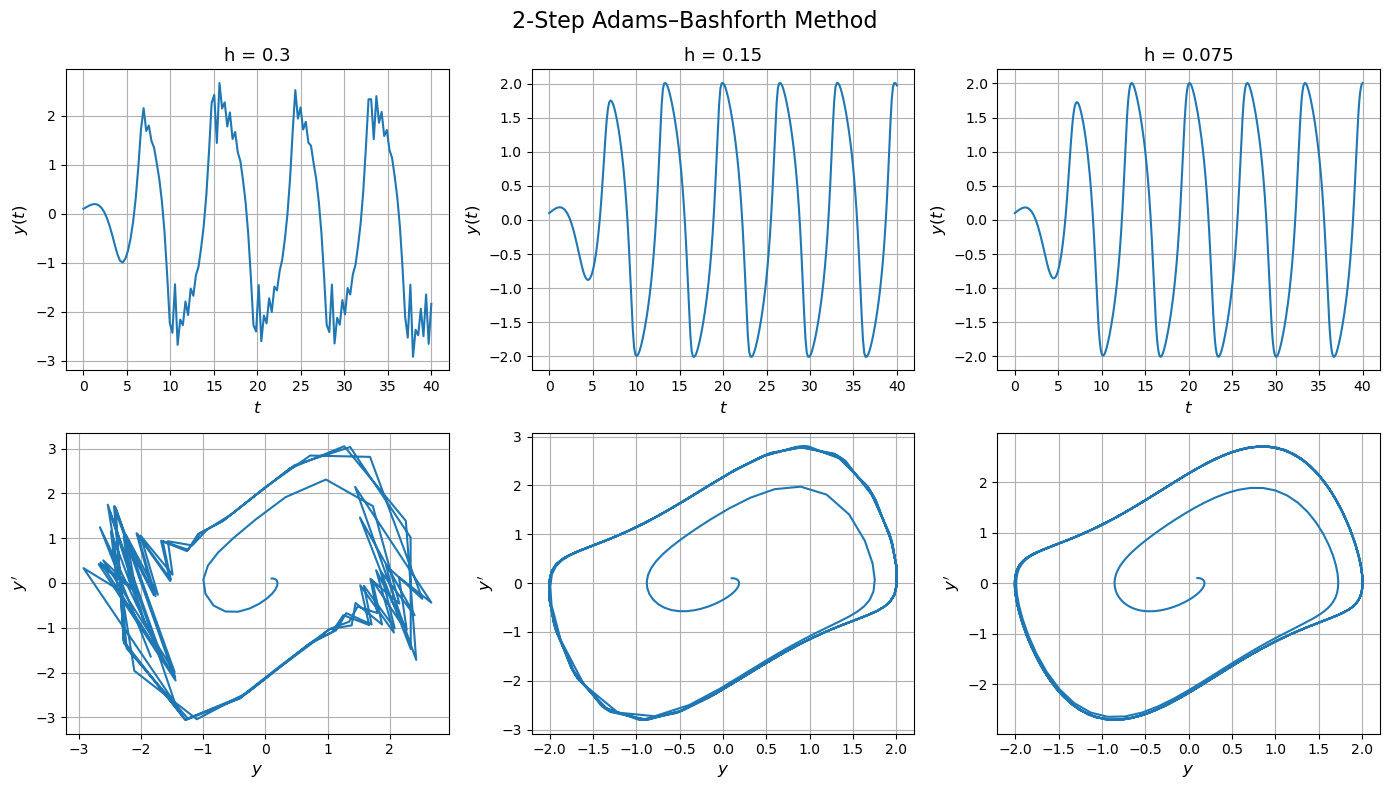

In [30]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

for j, h in enumerate(h_values):

    # Number of steps
    N = int((tmax - tmin)/h)

    # Time grid
    t = np.linspace(tmin, tmax, N+1)

    # Solution array
    y = np.zeros((2, N+1))
    y[:,0] = [0.1, 0.1]

    # Compute solution
    y_sol = AB(y, h)

    # ---- Physical space ----
    axs[0,j].plot(t, y_sol[0,:])
    axs[0,j].set_title(f"h = {h}", fontsize=13)
    axs[0,j].set_xlabel(r"$t$", fontsize=12)
    axs[0,j].set_ylabel(r"$y(t)$", fontsize=12)
    axs[0,j].grid(True)

    # ---- Phase plane ----
    axs[1,j].plot(y_sol[0,:], y_sol[1,:])
    axs[1,j].set_xlabel(r"$y$", fontsize=12)
    axs[1,j].set_ylabel(r"$y'$", fontsize=12)
    axs[1,j].grid(True)

fig.suptitle("2-Step Adams–Bashforth Method", fontsize=16)
plt.tight_layout()
plt.show()

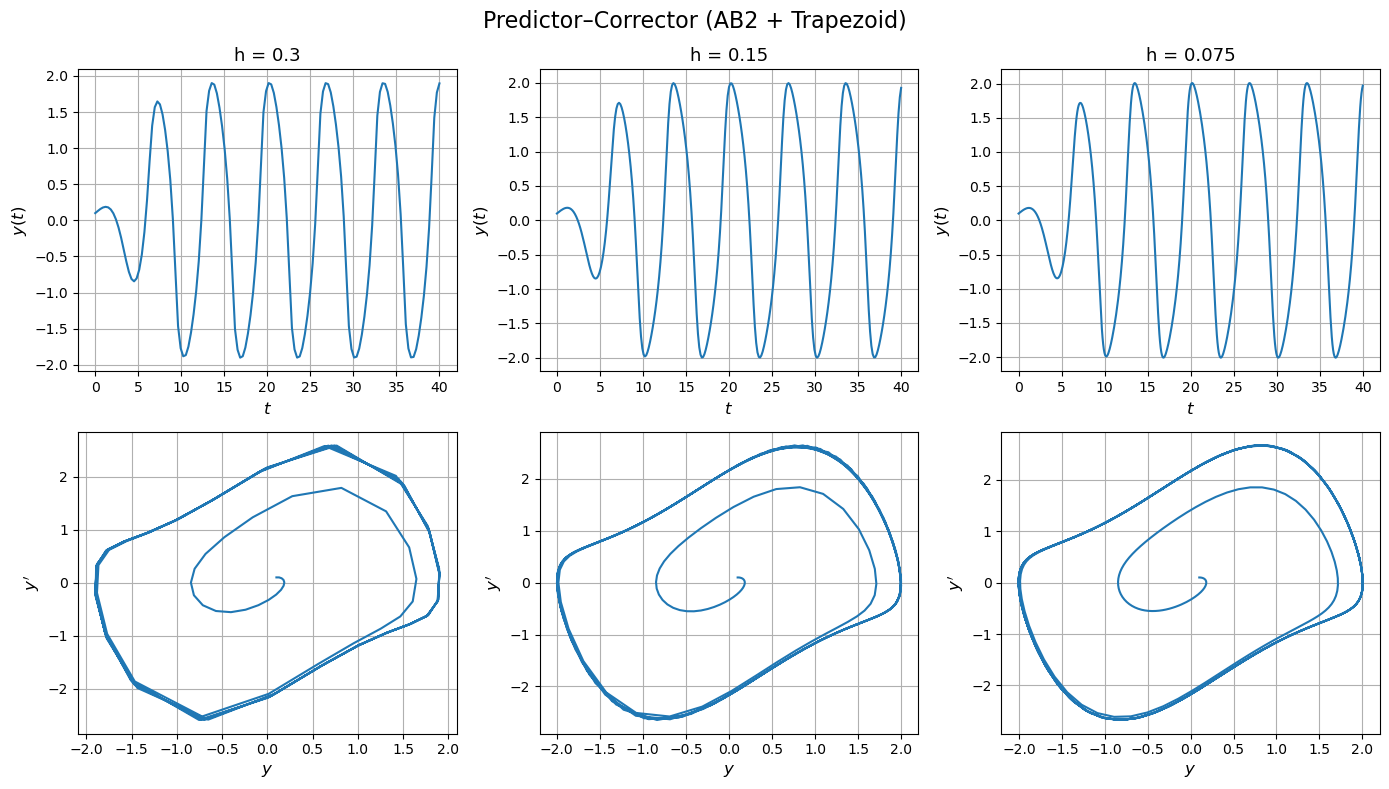

In [29]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

for j, h in enumerate(h_values):

    # Number of steps
    N = int((tmax - tmin)/h)

    # Time grid
    t = np.linspace(tmin, tmax, N+1)

    # Solution array
    y = np.zeros((2, N+1))
    y[:,0] = [0.1, 0.1]

    # Compute solution
    y_sol = predcorr(y, h)

    # ---- Physical space ----
    axs[0,j].plot(t, y_sol[0,:])
    axs[0,j].set_title(f"h = {h}", fontsize=13)
    axs[0,j].set_xlabel(r"$t$", fontsize=12)
    axs[0,j].set_ylabel(r"$y(t)$", fontsize=12)
    axs[0,j].grid(True)

    # ---- Phase plane ----
    axs[1,j].plot(y_sol[0,:], y_sol[1,:])
    axs[1,j].set_xlabel(r"$y$", fontsize=12)
    axs[1,j].set_ylabel(r"$y'$", fontsize=12)
    axs[1,j].grid(True)

fig.suptitle("Predictor–Corrector (AB2 + Trapezoid)", fontsize=16)
plt.tight_layout()
plt.show()